CES substitution elasticity sigma = 1/(1-rho_p) = 0.833
Baseline: {'Q': 0.292095123290222, 'L': 0.1481265636233925, 'w': 0.2841930923508837, 'I': 0.24209654617544185, 'P': 0.3695611823491277, 'pi': 0.04585047294610685}


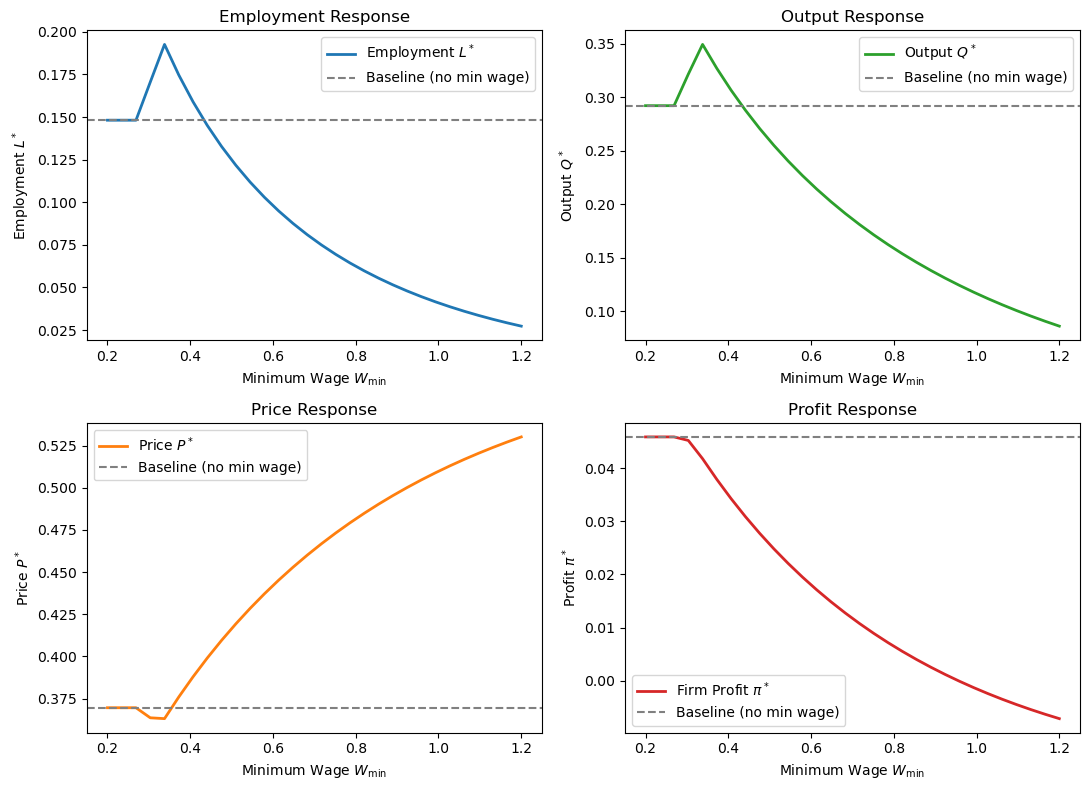

<Figure size 640x480 with 0 Axes>

In [4]:
import numpy as np
from scipy.optimize import minimize_scalar, brentq
import matplotlib.pyplot as plt

# ============================================================
#  PARAMETERS
# ============================================================

# ---------- Production (CES) ----------
A_prod = 1.0     # TFP / scale
K      = 1.0
r      = 0.02

delta  = 0.4     # weight on capital (higher => more capital-intensive)
rho_p  = -0.2    # CES rho (NOT the same as demand rho)
# Substitution elasticity: sigma = 1/(1 - rho_p)
# rho_p -> 0 approximates Cobb-Douglas; rho_p < 0 => complements-ish; rho_p > 0 => more substitutable

# ---------- Labor supply / preferences ----------
gamma = 1.0
Y0    = 0.2

# ---------- Goods-demand microfoundation (NONLINEAR) ----------
a_d  = 1.8
b_d  = 1.0
rho  = 0.7   # demand-side rho (income effect strength)

# ---------- Minimum wage grid ----------
W_list = np.linspace(0.2, 1.2, 30)

# ============================================================
#  CES TECHNOLOGY
# ============================================================

def Q_from_L(L):
    """
    CES production with fixed K:
      Q = A_prod * [delta*K^rho_p + (1-delta)*L^rho_p]^(1/rho_p)
    """
    L = float(L)
    if L <= 0:
        return 0.0

    # Handle Cobb-Douglas limit (rho_p -> 0) safely if you ever set rho_p very close to 0
    if abs(rho_p) < 1e-8:
        # Cobb-Douglas: Q = A_prod * K^delta * L^(1-delta)
        return A_prod * (K**delta) * (L**(1.0 - delta))

    inside = delta*(K**rho_p) + (1.0 - delta)*(L**rho_p)
    if inside <= 0:
        return 0.0
    return A_prod * (inside**(1.0/rho_p))

def L_required(Q):
    """
    Invert CES for L given Q (K fixed):
      Q/A_prod = [delta*K^rho_p + (1-delta)*L^rho_p]^(1/rho_p)
      => (Q/A_prod)^rho_p = delta*K^rho_p + (1-delta)*L^rho_p
      => L^rho_p = ((Q/A_prod)^rho_p - delta*K^rho_p)/(1-delta)
    """
    Q = float(Q)
    if Q <= 0:
        return 0.0

    # Cobb-Douglas limit
    if abs(rho_p) < 1e-8:
        # Q = A_prod * K^delta * L^(1-delta)  =>  L = (Q/(A_prod*K^delta))^(1/(1-delta))
        denom = A_prod * (K**delta)
        if denom <= 0:
            return np.inf
        return (Q/denom)**(1.0/(1.0 - delta))

    # CES inversion
    term = (Q / A_prod)**rho_p
    rhs = (term - delta*(K**rho_p)) / (1.0 - delta)

    # Feasibility: rhs must be > 0 to get real L
    if rhs <= 0:
        return np.inf

    L = rhs**(1.0/rho_p)
    if not np.isfinite(L) or L < 0:
        return np.inf
    return float(L)

# ============================================================
#  LABOR SUPPLY (from worker utility)
# ============================================================

def L_supply(w):
    if w <= 0:
        return 0.0
    L = 1/(1+gamma) - (gamma*Y0)/((1+gamma)*w)
    return float(np.clip(L, 0.0, 1.0))

def w_clearing(L):
    Lmax = 1/(1+gamma)
    if L >= Lmax:
        return np.inf
    return (gamma * Y0) / (1 - (1+gamma)*L)

# ============================================================
#  NONLINEAR PRICE FROM CONSUMER OPTIMIZATION
# ============================================================

def price_nonlinear(Q, I):
    """
    Solve: P = (a_d - b_d Q) * (I - P Q)^rho
    """
    if Q <= 0 or I <= 1e-12:
        return np.nan

    mu_q = a_d - b_d*Q
    if mu_q <= 0:
        return 0.0

    P_lo = 1e-10
    P_hi = (I/Q) * (1 - 1e-10)

    def f(P):
        c = I - P*Q
        if c <= 0:
            return 1e10
        return P - mu_q*(c**rho)

    if f(P_lo)*f(P_hi) > 0:
        return np.nan

    return brentq(f, P_lo, P_hi, maxiter=200)

# ============================================================
#  BASELINE: MONOPSONY, NO MINIMUM WAGE
# ============================================================

def solve_baseline():
    Lmax = 1/(1+gamma)
    Qcap = Q_from_L(Lmax)

    def profit(Q):
        if Q <= 0 or Q >= Qcap:
            return -np.inf

        L = L_required(Q)
        if not np.isfinite(L) or L <= 0 or L > Lmax + 1e-10:
            return -np.inf

        w = w_clearing(L)
        if not np.isfinite(w):
            return -np.inf

        I = w*L + Y0
        P = price_nonlinear(Q, I)
        if not np.isfinite(P) or P < 0:
            return -np.inf

        return P*Q - w*L - r*K

    res = minimize_scalar(lambda q: -profit(q),
                          bounds=(1e-8, Qcap-1e-8),
                          method="bounded")
    Q = float(res.x)
    L = float(L_required(Q))
    w = float(w_clearing(L))
    I = w*L + Y0
    P = float(price_nonlinear(Q, I))

    return dict(Q=Q, L=L, w=w, I=I, P=P, pi=float(profit(Q)))

# ============================================================
#  MINIMUM WAGE
# ============================================================

def solve_minwage(Wmin, base):
    if Wmin <= base["w"]:
        out = dict(base)
        out["Wmin"] = Wmin
        out["binds"] = False
        return out

    Lcap = L_supply(Wmin)
    Qcap = Q_from_L(Lcap)
    if Qcap <= 1e-8:
        return None

    def profit(Q):
        if Q <= 0 or Q >= Qcap:
            return -np.inf

        L = L_required(Q)
        if not np.isfinite(L) or L <= 0 or L > Lcap + 1e-10:
            return -np.inf

        I = Wmin*L + Y0
        P = price_nonlinear(Q, I)
        if not np.isfinite(P) or P < 0:
            return -np.inf

        return P*Q - Wmin*L - r*K

    res = minimize_scalar(lambda q: -profit(q),
                          bounds=(1e-8, Qcap-1e-8),
                          method="bounded")
    if not res.success:
        return None

    Q = float(res.x)
    L = float(L_required(Q))
    I = Wmin*L + Y0
    P = float(price_nonlinear(Q, I))

    return dict(Wmin=Wmin, Q=Q, L=L, w=float(Wmin), I=I, P=P, pi=float(profit(Q)), binds=True)

# ============================================================
#  RUN
# ============================================================

print(f"CES substitution elasticity sigma = 1/(1-rho_p) = {1.0/(1.0-rho_p):.3f}")

base = solve_baseline()
print("Baseline:", base)

L_list, Q_list, P_list, pi_list, U_list = [], [], [], [], []

for W in W_list:
    out = solve_minwage(W, base)
    if out is None:
        L_list.append(np.nan)
        Q_list.append(np.nan)
        P_list.append(np.nan)
        pi_list.append(np.nan)
        U_list.append(np.nan)
        continue

    L = out["L"]
    Q = out["Q"]
    w = out["w"]
    I = out["I"]
    C = I

    U = np.log(C) + gamma*np.log(1-L)

    L_list.append(L)
    Q_list.append(Q)
    P_list.append(out["P"])
    pi_list.append(out["pi"])
    U_list.append(U)

# ============================================================
#  PLOTS (Improved & Publication-Ready)
# ============================================================

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax = ax.flatten()

# ---------- Labor ----------
ax[0].plot(
    W_list, L_list,
    color="tab:blue", lw=2, label="Employment $L^*$"
)
ax[0].axhline(
    base["L"], color="gray", linestyle="--", lw=1.5,
    label="Baseline (no min wage)"
)
ax[0].set_title("Employment Response")
ax[0].set_xlabel("Minimum Wage $W_{\\min}$")
ax[0].set_ylabel("Employment $L^*$")
ax[0].legend()

# ---------- Output ----------
ax[1].plot(
    W_list, Q_list,
    color="tab:green", lw=2, label="Output $Q^*$"
)
ax[1].axhline(
    base["Q"], color="gray", linestyle="--", lw=1.5,
    label="Baseline (no min wage)"
)
ax[1].set_title("Output Response")
ax[1].set_xlabel("Minimum Wage $W_{\\min}$")
ax[1].set_ylabel("Output $Q^*$")
ax[1].legend()

# ---------- Price ----------
ax[2].plot(
    W_list, P_list,
    color="tab:orange", lw=2, label="Price $P^*$"
)
ax[2].axhline(
    base["P"], color="gray", linestyle="--", lw=1.5,
    label="Baseline (no min wage)"
)
ax[2].set_title("Price Response")
ax[2].set_xlabel("Minimum Wage $W_{\\min}$")
ax[2].set_ylabel("Price $P^*$")
ax[2].legend()

# ---------- Profit ----------
ax[3].plot(
    W_list, pi_list,
    color="tab:red", lw=2, label="Firm Profit $\\pi^*$"
)
ax[3].axhline(
    base["pi"], color="gray", linestyle="--", lw=1.5,
    label="Baseline (no min wage)"
)
ax[3].set_title("Profit Response")
ax[3].set_xlabel("Minimum Wage $W_{\\min}$")
ax[3].set_ylabel("Profit $\\pi^*$")
ax[3].legend()

# ---------- Layout & Save ----------
plt.tight_layout()

# Save figure for paper (high resolution)
plt.savefig(
    "minimum_wage_CES_equilibrium_responses.png",
    dpi=300, bbox_inches="tight"
)

plt.show()

plt.savefig("minimum_wage_CES_results.png", dpi=300, bbox_inches="tight")


plt.savefig("minimum_wage_CES_results.pdf", bbox_inches="tight")

plt.show()

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar, brentq

# ============================================================
#  GLOBAL CONSTANTS
# ============================================================

A_prod = 1.0
K      = 1.0
r      = 0.02
Y0     = 0.2
a_d    = 1.8
b_d    = 1.0

W_list = np.linspace(0.2, 1.2, 120)   # 更密，避免“单点区间”
TOL    = 1e-6
NEGVAL = -1e30

# ============================================================
#  CES PRODUCTION
# ============================================================

def Q_from_L(L, delta, rho_p):
    if L <= 0:
        return 0.0
    if abs(rho_p) < 1e-8:
        return A_prod * (K**delta) * (L**(1-delta))
    inside = delta*K**rho_p + (1-delta)*L**rho_p
    if inside <= 0:
        return 0.0
    return A_prod * inside**(1/rho_p)

def L_required(Q, delta, rho_p):
    if Q <= 0:
        return 0.0
    if abs(rho_p) < 1e-8:
        denom = A_prod * (K**delta)
        return (Q/denom)**(1/(1-delta))
    rhs = ((Q/A_prod)**rho_p - delta*K**rho_p)/(1-delta)
    if rhs <= 0:
        return np.inf
    L = rhs**(1/rho_p)
    return L if np.isfinite(L) and L > 0 else np.inf

# ============================================================
#  LABOR SUPPLY
# ============================================================

def L_supply(w, gamma):
    if w <= 0:
        return 0.0
    L = 1/(1+gamma) - (gamma*Y0)/((1+gamma)*w)
    return float(np.clip(L, 0.0, 1.0))

def w_clearing(L, gamma):
    Lmax = 1/(1+gamma)
    if L >= Lmax:
        return np.inf
    return (gamma * Y0) / (1 - (1+gamma)*L)

# ============================================================
#  NONLINEAR DEMAND (ROBUST)
# ============================================================

def price_nonlinear(Q, I, rho_d):
    if Q <= 0 or I <= 1e-12:
        return np.nan
    mu = a_d - b_d*Q
    if mu <= 0:
        return 0.0

    P_lo = 1e-10
    P_hi = (I/Q) * (1 - 1e-10)

    def f(P):
        c = I - P*Q
        if c <= 0:
            return 1e10
        return P - mu*(c**rho_d)

    if f(P_lo)*f(P_hi) > 0:
        return np.nan

    return brentq(f, P_lo, P_hi, maxiter=200)

# ============================================================
#  SOLVERS
# ============================================================

def solve_baseline(delta, rho_p, rho_d, gamma):
    Lmax = 1/(1+gamma)
    Qcap = Q_from_L(Lmax, delta, rho_p)

    def profit(Q):
        if Q <= 0 or Q >= Qcap:
            return NEGVAL
        L = L_required(Q, delta, rho_p)
        if not np.isfinite(L) or L <= 0 or L > Lmax:
            return NEGVAL
        w = w_clearing(L, gamma)
        if not np.isfinite(w):
            return NEGVAL
        I = w*L + Y0
        P = price_nonlinear(Q, I, rho_d)
        if not np.isfinite(P) or P <= 0:
            return NEGVAL
        return P*Q - w*L - r*K

    res = minimize_scalar(lambda q: -profit(q),
                          bounds=(1e-8, Qcap-1e-8),
                          method="bounded")
    Q = res.x
    return Q

def solve_minwage(W, Q0, delta, rho_p, rho_d, gamma):
    Lcap = L_supply(W, gamma)
    Qcap = Q_from_L(Lcap, delta, rho_p)
    if Qcap <= 1e-8:
        return np.nan

    def profit(Q):
        if Q <= 0 or Q >= Qcap:
            return NEGVAL
        L = L_required(Q, delta, rho_p)
        if not np.isfinite(L) or L <= 0 or L > Lcap:
            return NEGVAL
        I = W*L + Y0
        P = price_nonlinear(Q, I, rho_d)
        if not np.isfinite(P) or P <= 0:
            return NEGVAL
        return P*Q - W*L - r*K

    res = minimize_scalar(lambda q: -profit(q),
                          bounds=(1e-8, Qcap-1e-8),
                          method="bounded")
    return res.x if res.success else np.nan

# ============================================================
#  INTERVAL UTILS
# ============================================================

def find_intervals(W, Q, Q0):
    mask = Q > Q0 + TOL
    intervals, start = [], None
    for i in range(len(W)):
        if mask[i] and start is None:
            start = W[i]
        if (not mask[i] or i == len(W)-1) and start is not None:
            end = W[i-1] if not mask[i] else W[i]
            intervals.append((start, end))
            start = None
    return intervals

def format_intervals(intervals):
    if not intervals:
        return "None"
    out = []
    for a,b in intervals:
        if abs(a-b) < 1e-3:
            out.append(f"{a:.3f}")
        else:
            out.append(f"{a:.3f}–{b:.3f}")
    return "; ".join(out)

# ============================================================
#  PARAMETER GRIDS (5 BINS)
# ============================================================

experiments = [
    ("Capital–Labor Substitutability (ρ_p)", 
     [-0.8, -0.4, 0.0, 0.3, 0.6], 
     lambda v: f"σ={1/(1-v):.2f}"),
    ("Capital Intensity (δ)", 
     [0.2, 0.35, 0.5, 0.65, 0.8], 
     lambda v: ""),
    ("Income Sensitivity (ρ_d)", 
     [0.1, 0.3, 0.6, 1.0, 1.5], 
     lambda v: ""),
    ("Labor Supply Elasticity (γ)", 
     [0.3, 0.6, 1.0, 1.5, 2.5], 
     lambda v: "")
]

# ============================================================
#  RUN ALL
# ============================================================

rows = []

for dim, grid, extra in experiments:
    for level, val in enumerate(grid, 1):

        delta, rho_p, rho_d, gamma = 0.5, 0.0, 0.6, 1.0
        if "ρ_p" in dim: rho_p = val
        if "δ"   in dim: delta = val
        if "ρ_d" in dim: rho_d = val
        if "γ"   in dim: gamma = val

        Q0 = solve_baseline(delta, rho_p, rho_d, gamma)
        Q_list = np.array([solve_minwage(W, Q0, delta, rho_p, rho_d, gamma) for W in W_list])
        intervals = find_intervals(W_list, Q_list, Q0)

        rows.append({
            "Dimension": dim,
            "Level (1–5)": level,
            "Parameter value": val,
            "Economic meaning": extra(val),
            "Baseline output Q": round(Q0,4),
            "Output-increasing W_min interval": format_intervals(intervals)
        })

df = pd.DataFrame(rows)
print(df)


                               Dimension  Level (1–5)  Parameter value  \
0   Capital–Labor Substitutability (ρ_p)            1            -0.80   
1   Capital–Labor Substitutability (ρ_p)            2            -0.40   
2   Capital–Labor Substitutability (ρ_p)            3             0.00   
3   Capital–Labor Substitutability (ρ_p)            4             0.30   
4   Capital–Labor Substitutability (ρ_p)            5             0.60   
5                  Capital Intensity (δ)            1             0.20   
6                  Capital Intensity (δ)            2             0.35   
7                  Capital Intensity (δ)            3             0.50   
8                  Capital Intensity (δ)            4             0.65   
9                  Capital Intensity (δ)            5             0.80   
10              Income Sensitivity (ρ_d)            1             0.10   
11              Income Sensitivity (ρ_d)            2             0.30   
12              Income Sensitivity (ρ_